# Comprehensive Summary — Price Elasticity of Demand, Amazon Shoes (Size 8)

*Replication & extension of Victor et al. (2025), "Adventures in Demand Analysis Using AI."*

This notebook consolidates **every elasticity result in the project** and analyzes them in
depth. It is the single source of truth for the headline numbers, the robustness checks, and
the experimental comparison that motivated the whole pipeline.

**What is compared (14 result sets):**
| Track | Folders | Embeddings |
|---|---|---|
| Whole-gender originals | `men-8`, `women-8` | trained on all of that gender's products |
| **Lazy** subcat splits | `*-lazy-embedding` | reuse the whole-gender embeddings |
| **Proper** subcat splits | `*-proper-embedding` | trained *within* each subcategory (LoRA) |

**Central questions.** (1) Does the price elasticity of demand differ *within* a gender, by
product subcategory? (2) Does training embeddings within a subcategory ("proper") change the
answer versus the cheap shortcut of reusing whole-gender embeddings ("lazy")? (3) Do product
*images* add information beyond text? (4) Is the elasticity *heterogeneous* across products?

**Estimation.** DoubleML Partially Linear Regression (LightGBM nuisance learners, 5-fold
cross-fitting, SEs clustered by product). Five control specifications per experiment. Outcome
is Δ negative-log sales-rank; following He & Hollenbeck (2020) / Victor et al. Remark 1 we
convert the rank-elasticity to a **demand (quantity) elasticity** by ×1/ϑ (ϑ=0.6 → ×1.667),
and report both. Two embedding variants (text-only, text+image) throughout.

## ① Data collection

In [1]:
import os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
sns.set_style("whitegrid"); palette = sns.color_palette("colorblind")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT/"men-8-whole").is_dir() and (ROOT/"women-8-whole").is_dir(): break
    ROOT = ROOT.parent
HERE = ROOT/"summary"; (HERE/"data").mkdir(parents=True, exist_ok=True); (HERE/"figures").mkdir(parents=True, exist_ok=True)

NTRAIN = {("men","ALL"):1029,("women","ALL"):2573,
          ("men","loafers-slip-ons"):180,("men","fashion-sneakers"):172,("men","oxfords"):130,
          ("women","pumps"):626,("women","flats"):496,("women","fashion-sneakers"):430}
REG = [("men","whole","ALL","men-8-whole"),("women","whole","ALL","women-8-whole")]
for g, scs in [("men",["loafers-slip-ons","fashion-sneakers","oxfords"]),
               ("women",["pumps","flats","fashion-sneakers"])]:
    for emb in ("lazy","proper"):
        for sc in scs: REG.append((g,emb,sc,f"{g}-8-subcat-split-{emb}-embedding/{sc}"))

def _read(folder,fname):
    for sub in ("04_evaluation_v2_delta","04_evaluation"):
        p=ROOT/folder/"output"/sub/fname
        if p.exists(): return pd.read_csv(p)
    return None

E,H=[],[]
for g,emb,sc,folder in REG:
    e=_read(folder,"comparison_elasticity.csv")
    if e is not None: E.append(e.assign(gender=g,embedding=emb,subcat=sc))
    h=_read(folder,"comparison_cate_het.csv")
    if h is not None: H.append(h.assign(gender=g,embedding=emb,subcat=sc))
elas=pd.concat(E,ignore_index=True); cate=pd.concat(H,ignore_index=True) if H else pd.DataFrame()
for df in (elas,cate):
    df["n_train"]=df.apply(lambda r:NTRAIN.get((r["gender"],r["subcat"]),np.nan),axis=1)
    df["label"]=df.apply(lambda r:(f"{r['gender']}-8 whole" if r["subcat"]=="ALL" else f"{r['gender']}/{r['subcat']}"),axis=1)
# significance at the 90% level: CI excludes 0
elas["sig"]=(np.sign(elas["rank_lower"])==np.sign(elas["rank_upper"]))
SPECS=["PLR + Emb + Controls","PLR + Embeddings","PLR + Controls","PLR + Similarities + Controls","PLR + PCA + Controls"]
MAIN="PLR + Emb + Controls"
print(f"loaded {len(elas)} elasticity rows ({elas['label'].nunique()} experiments x {elas['spec'].nunique()} specs x 2 variants) and {len(cate)} CATE/het rows")

loaded 140 elasticity rows (8 experiments x 5 specs x 2 variants) and 28 CATE/het rows


## ② Executive summary

In [2]:
def dc(label,emb,variant="txtimg",spec=MAIN):
    r=elas[(elas.label==label)&(elas.embedding==emb)&(elas.variant==variant)&(elas.spec==spec)]
    return float(r["demand_coef"].iloc[0]) if len(r) else float("nan")
lines=[]
lines.append(f"Whole-gender demand elasticity (main spec, txt+img): men-8 = {dc('men-8 whole','whole'):+.3f}, "
             f"women-8 = {dc('women-8 whole','whole'):+.3f}.")
wsub=elas[(elas.gender=='women')&(elas.embedding=='proper')&(elas.variant=='txtimg')&(elas.spec==MAIN)]
lines.append(f"Within women (proper, txt+img), subcat demand elasticity ranges {wsub['demand_coef'].min():+.3f} "
             f"(most elastic) to {wsub['demand_coef'].max():+.3f} (least), vs a single whole-gender {dc('women-8 whole','whole'):+.3f} "
             f"-> aggregation hides a {abs(wsub['demand_coef'].max()-wsub['demand_coef'].min()):.3f} spread.")
# lazy vs proper mean abs gap on women
piv=elas[(elas.spec==MAIN)&(elas.variant=='txtimg')&(elas.subcat!='ALL')].pivot_table(index=['gender','subcat'],columns='embedding',values='demand_coef')
gap_w=(piv.loc['women','proper']-piv.loc['women','lazy']).abs().mean()
gap_m=(piv.loc['men','proper']-piv.loc['men','lazy']).abs().mean()
lines.append(f"Lazy-vs-proper mean |gap| (demand, txt+img): women {gap_w:.3f} (small -> shortcut roughly holds), "
             f"men {gap_m:.3f} (large -> tiny-N noise).")
sigshare=elas[(elas.spec==MAIN)&(elas.variant=='txtimg')].groupby('embedding')['sig'].mean()
lines.append("Share of main-spec estimates significant at 90% (txt+img): " + ", ".join(f"{k} {v:.0%}" for k,v in sigshare.items()))
print("EXECUTIVE SUMMARY\n"+"="*70)
for i,l in enumerate(lines,1): print(f"{i}. {l}\n")

EXECUTIVE SUMMARY
1. Whole-gender demand elasticity (main spec, txt+img): men-8 = -0.169, women-8 = -0.172.

2. Within women (proper, txt+img), subcat demand elasticity ranges -0.232 (most elastic) to -0.095 (least), vs a single whole-gender -0.172 -> aggregation hides a 0.137 spread.

3. Lazy-vs-proper mean |gap| (demand, txt+img): women 0.058 (small -> shortcut roughly holds), men 0.250 (large -> tiny-N noise).

4. Share of main-spec estimates significant at 90% (txt+img): lazy 50%, proper 67%, whole 100%



## ③ Master results table (all experiments × specifications × variants)

Saved to `data/master_elasticities.csv`.

In [3]:
cols=["gender","embedding","subcat","n_train","spec","variant","rank_lower","rank_coef","rank_upper",
      "demand_lower","demand_coef","demand_upper","sig"]
master=elas[cols].sort_values(["gender","embedding","subcat","spec","variant"]).reset_index(drop=True)
master.round(4).to_csv(HERE/"data"/"master_elasticities.csv",index=False)
print(f"{len(master)} rows -> data/master_elasticities.csv"); master.head(10).round(4)

140 rows -> data/master_elasticities.csv


,gender,embedding,subcat,n_train,spec,variant,rank_lower,rank_coef,rank_upper,demand_lower,demand_coef,demand_upper,sig
0,men,lazy,fashion-sneakers,172,PLR + Controls,txt,-0.5615,-0.3275,-0.0935,-0.9358,-0.5458,-0.1558,True
1,men,lazy,fashion-sneakers,172,PLR + Controls,txtimg,-0.6033,-0.3720,-0.1407,-1.0055,-0.6201,-0.2346,True
2,men,lazy,fashion-sneakers,172,PLR + Emb + Controls,txt,-0.7093,-0.5014,-0.2935,-1.1821,-0.8356,-0.4891,True
3,men,lazy,fashion-sneakers,172,PLR + Emb + Controls,txtimg,-0.4723,-0.2255,0.0212,-0.7871,-0.3759,0.0353,False
4,men,lazy,fashion-sneakers,172,PLR + Embeddings,txt,-0.8353,-0.4899,-0.1445,-1.3921,-0.8164,-0.2408,True
5,men,lazy,fashion-sneakers,172,PLR + Embeddings,txtimg,-0.5492,-0.3042,-0.0592,-0.9154,-0.5070,-0.0987,True
6,men,lazy,fashion-sneakers,172,PLR + PCA + Controls,txt,-0.6345,-0.3834,-0.1324,-1.0575,-0.6391,-0.2207,True
7,men,lazy,fashion-sneakers,172,PLR + PCA + Controls,txtimg,-0.7351,-0.4508,-0.1666,-1.2251,-0.7514,-0.2776,True
8,men,lazy,fashion-sneakers,172,PLR + Similarities + Controls,txt,-0.6454,-0.4024,-0.1593,-1.0757,-0.6706,-0.2655,True
9,men,lazy,fashion-sneakers,172,PLR + Similarities + Controls,txtimg,-0.7098,-0.4076,-0.1053,-1.1830,-0.6793,-0.1755,True


## ④ Whole-gender baselines (men-8, women-8)

The reference point before splitting. All 5 specifications, demand elasticity (90% CI),
text+image. The estimate is stable across control sets (embeddings vs tabular vs both), which
is the robustness check: the result is not an artifact of one control choice.

label                          men-8 whole  women-8 whole
spec                                                     
PLR + Emb + Controls                -0.169         -0.172
PLR + Embeddings                    -0.186         -0.229
PLR + Controls                      -0.191         -0.150
PLR + Similarities + Controls       -0.225         -0.162
PLR + PCA + Controls                -0.228         -0.159


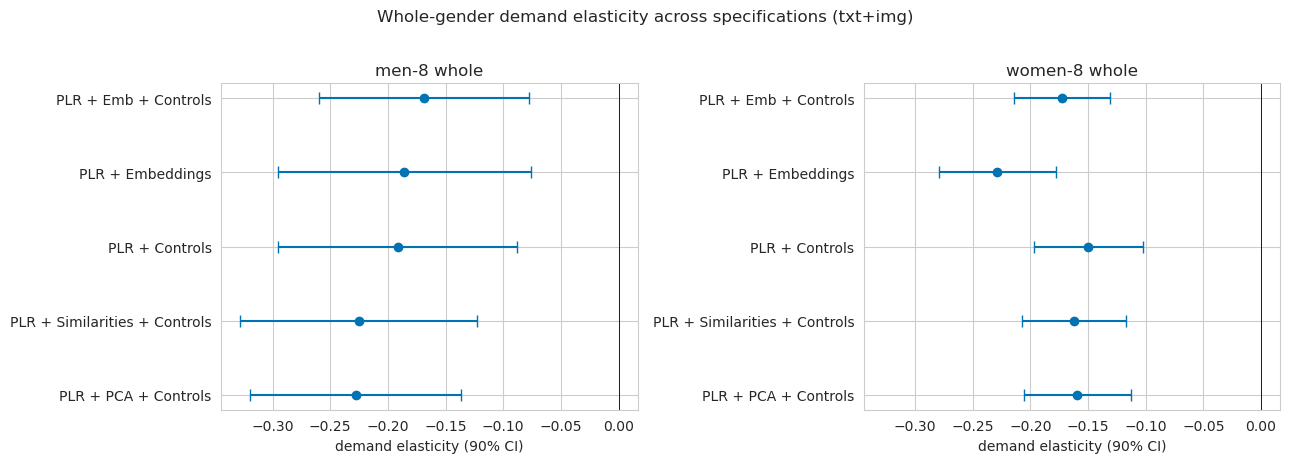

In [4]:
base=elas[(elas.subcat=="ALL")&(elas.variant=="txtimg")][["label","spec","demand_coef","demand_lower","demand_upper","sig"]]
print(base.pivot_table(index="spec",columns="label",values="demand_coef").reindex(SPECS).round(3).to_string())
fig,axes=plt.subplots(1,2,figsize=(13,4.5),sharex=True)
for ax,lab in zip(axes,["men-8 whole","women-8 whole"]):
    d=base[base.label==lab].set_index("spec").reindex(SPECS)
    y=range(len(d))
    ax.errorbar(d["demand_coef"],y,xerr=[d["demand_coef"]-d["demand_lower"],d["demand_upper"]-d["demand_coef"]],
                fmt="o",capsize=4,color=palette[0])
    ax.axvline(0,color="k",lw=.6); ax.set_yticks(list(y)); ax.set_yticklabels(SPECS); ax.invert_yaxis()
    ax.set_title(lab); ax.set_xlabel("demand elasticity (90% CI)")
fig.suptitle("Whole-gender demand elasticity across specifications (txt+img)",y=1.02)
fig.tight_layout(); fig.savefig(HERE/"figures"/"01_whole_gender_specs.png",dpi=140,bbox_inches="tight"); plt.show()

## ⑤ Within-gender heterogeneity — aggregation hides variation

The whole-gender model returns one number per gender (≈ −0.17 each). But splitting by
subcategory (proper embeddings) reveals a wide spread the single number conceals. The dashed
line is the whole-gender estimate; bars are the subcategory estimates with 90% CIs.

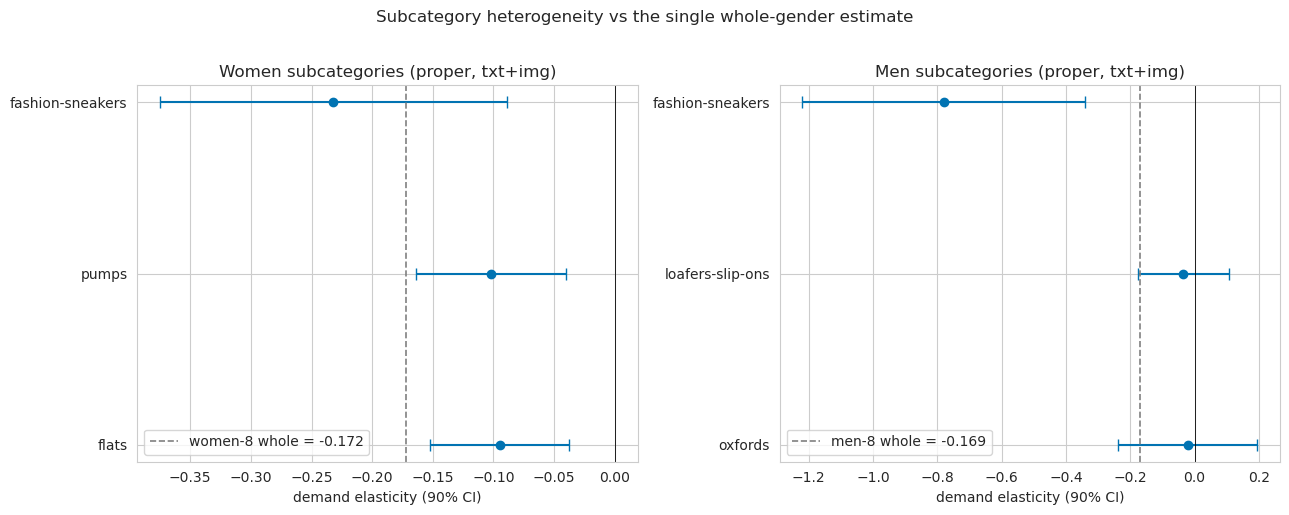

women: subcat demand elasticity range [-0.232, -0.095], whole-gender -0.172
men: subcat demand elasticity range [-0.781, -0.022], whole-gender -0.169


In [5]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,g in zip(axes,["women","men"]):
    d=elas[(elas.gender==g)&(elas.embedding=="proper")&(elas.variant=="txtimg")&(elas.spec==MAIN)&(elas.subcat!="ALL")].copy()
    d=d.sort_values("demand_coef")
    y=range(len(d))
    ax.errorbar(d["demand_coef"],y,xerr=[d["demand_coef"]-d["demand_lower"],d["demand_upper"]-d["demand_coef"]],
                fmt="o",capsize=4,color=palette[0],ecolor=palette[0])
    w=elas[(elas.gender==g)&(elas.subcat=="ALL")&(elas.variant=="txtimg")&(elas.spec==MAIN)]["demand_coef"].iloc[0]
    ax.axvline(w,color="gray",ls="--",lw=1.2,label=f"{g}-8 whole = {w:+.3f}")
    ax.axvline(0,color="k",lw=.6); ax.set_yticks(list(y)); ax.set_yticklabels(d["subcat"]); ax.invert_yaxis()
    ax.set_title(f"{g.title()} subcategories (proper, txt+img)"); ax.set_xlabel("demand elasticity (90% CI)"); ax.legend()
fig.suptitle("Subcategory heterogeneity vs the single whole-gender estimate",y=1.02)
fig.tight_layout(); fig.savefig(HERE/"figures"/"02_heterogeneity.png",dpi=140,bbox_inches="tight"); plt.show()
# table: spread per gender
for g in ("women","men"):
    d=elas[(elas.gender==g)&(elas.embedding=="proper")&(elas.variant=="txtimg")&(elas.spec==MAIN)&(elas.subcat!="ALL")]
    print(f"{g}: subcat demand elasticity range [{d['demand_coef'].min():+.3f}, {d['demand_coef'].max():+.3f}], "
          f"whole-gender {elas[(elas.gender==g)&(elas.subcat=='ALL')&(elas.variant=='txtimg')&(elas.spec==MAIN)]['demand_coef'].iloc[0]:+.3f}")

## ⑥ The core experiment — lazy vs proper embeddings

For each subcategory: the proper (within-subcat) vs lazy (whole-gender-reuse) demand
elasticity, the gap, and whether their 90% CIs overlap (overlap → not statistically
distinguishable). Main spec, text+image.

                subcat  n_train  proper   lazy    gap  CI_overlap  proper_sig  lazy_sig
           women/pumps      626  -0.102 -0.161  0.059        True        True      True
           women/flats      496  -0.095 -0.104  0.010        True        True      True
women/fashion-sneakers      430  -0.232 -0.337  0.105        True        True      True
  men/loafers-slip-ons      180  -0.035 -0.120  0.085        True       False     False
  men/fashion-sneakers      172  -0.781 -0.376 -0.405        True        True     False
           men/oxfords      130  -0.022  0.240 -0.262        True       False     False


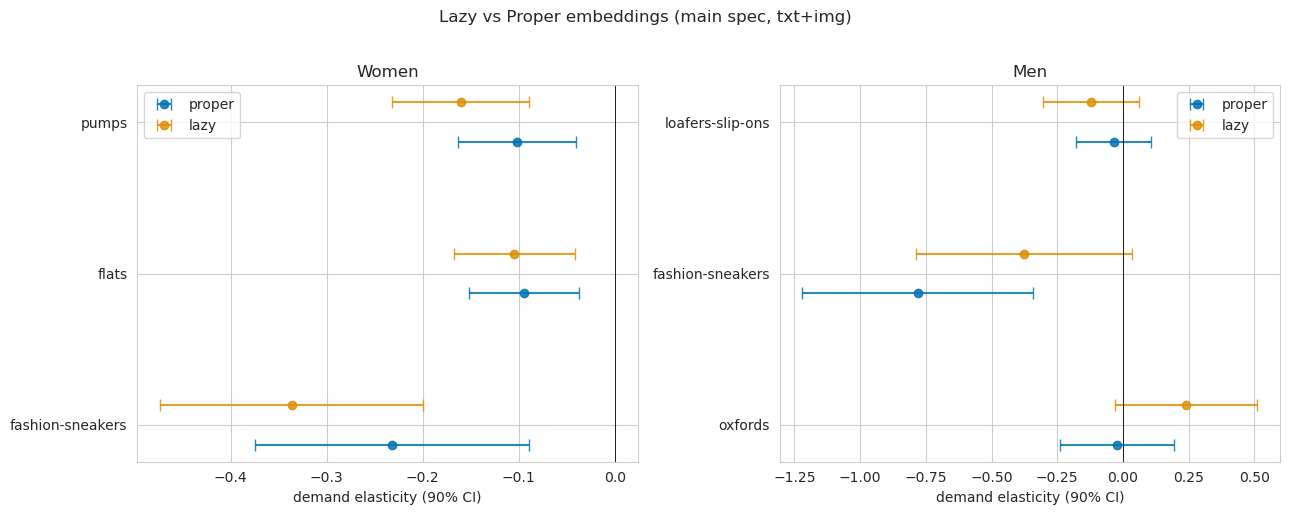

In [6]:
def overlap(lo1,hi1,lo2,hi2): return not (hi1<lo2 or hi2<lo1)
rows=[]
for g,sc in [(g,s) for g in("women","men") for s in elas[(elas.gender==g)&(elas.subcat!="ALL")]["subcat"].unique()]:
    p=elas[(elas.gender==g)&(elas.subcat==sc)&(elas.embedding=="proper")&(elas.variant=="txtimg")&(elas.spec==MAIN)]
    l=elas[(elas.gender==g)&(elas.subcat==sc)&(elas.embedding=="lazy")&(elas.variant=="txtimg")&(elas.spec==MAIN)]
    if not len(p) or not len(l): continue
    p,l=p.iloc[0],l.iloc[0]
    rows.append({"subcat":f"{g}/{sc}","n_train":int(p["n_train"]),
                 "proper":round(p["demand_coef"],3),"lazy":round(l["demand_coef"],3),
                 "gap":round(p["demand_coef"]-l["demand_coef"],3),
                 "CI_overlap":overlap(p["demand_lower"],p["demand_upper"],l["demand_lower"],l["demand_upper"]),
                 "proper_sig":bool(p["sig"]),"lazy_sig":bool(l["sig"])})
lp=pd.DataFrame(rows).sort_values("n_train",ascending=False)
lp.to_csv(HERE/"data"/"lazy_vs_proper.csv",index=False)
print(lp.to_string(index=False))
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,g in zip(axes,["women","men"]):
    d=elas[(elas.gender==g)&(elas.subcat!="ALL")&(elas.variant=="txtimg")&(elas.spec==MAIN)]
    scs=list(d["subcat"].unique()); off={"lazy":-0.13,"proper":0.13}; cc={"lazy":palette[1],"proper":palette[0]}
    for emb in ("proper","lazy"):
        dd=d[d.embedding==emb].set_index("subcat").reindex(scs)
        ax.errorbar(dd["demand_coef"],[scs.index(s)+off[emb] for s in scs],
                    xerr=[dd["demand_coef"]-dd["demand_lower"],dd["demand_upper"]-dd["demand_coef"]],
                    fmt="o",capsize=4,color=cc[emb],ecolor=cc[emb],label=emb,alpha=.85)
    ax.axvline(0,color="k",lw=.6); ax.set_yticks(range(len(scs))); ax.set_yticklabels(scs); ax.invert_yaxis()
    ax.set_title(f"{g.title()}"); ax.set_xlabel("demand elasticity (90% CI)"); ax.legend()
fig.suptitle("Lazy vs Proper embeddings (main spec, txt+img)",y=1.02)
fig.tight_layout(); fig.savefig(HERE/"figures"/"03_lazy_vs_proper.png",dpi=140,bbox_inches="tight"); plt.show()

## ⑦ Robustness across specifications

How much does the estimate move as we change the controls (embeddings only → tabular only →
both → similarities → PCA)? A tight band = robust; a wide band = control-sensitive (typical of
the tiny-N subcats). Heatmap of demand elasticity (txt+img).

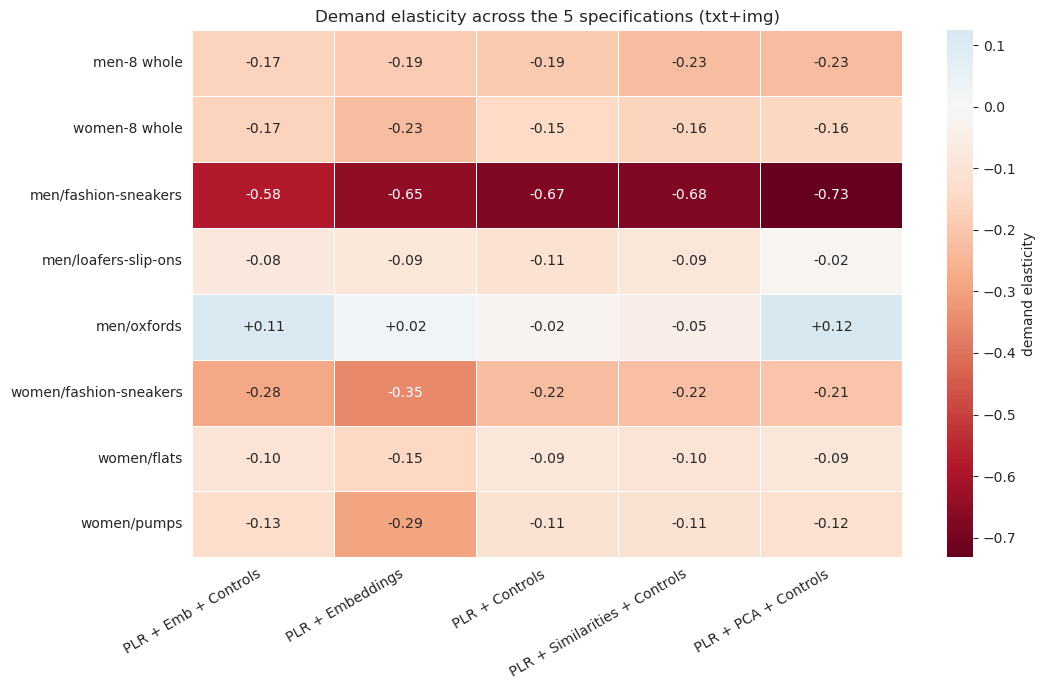

Across-spec spread (max-min demand elasticity), larger = less robust:
label
women/pumps               0.186
men/oxfords               0.175
men/fashion-sneakers      0.154
women/fashion-sneakers    0.143
men/loafers-slip-ons      0.094
women-8 whole             0.079
women/flats               0.062
men-8 whole               0.059


In [7]:
piv=elas[(elas.variant=="txtimg")].pivot_table(index="label",columns="spec",values="demand_coef")[SPECS]
order=["men-8 whole","women-8 whole"]+[l for l in piv.index if l not in ("men-8 whole","women-8 whole")]
piv=piv.reindex(order)
fig,ax=plt.subplots(figsize=(11,7))
sns.heatmap(piv,annot=True,fmt="+.2f",cmap="RdBu",center=0,cbar_kws={"label":"demand elasticity"},ax=ax,linewidths=.5)
ax.set_title("Demand elasticity across the 5 specifications (txt+img)"); ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=30,ha="right"); fig.tight_layout(); fig.savefig(HERE/"figures"/"04_spec_robustness.png",dpi=140,bbox_inches="tight"); plt.show()
spread=piv.max(axis=1)-piv.min(axis=1)
print("Across-spec spread (max-min demand elasticity), larger = less robust:")
print(spread.round(3).sort_values(ascending=False).to_string())

## ⑧ Does adding images help? (text+image vs text-only)

Main-spec demand elasticity, both variants, per experiment. Points below the diagonal = images make the estimate more elastic.

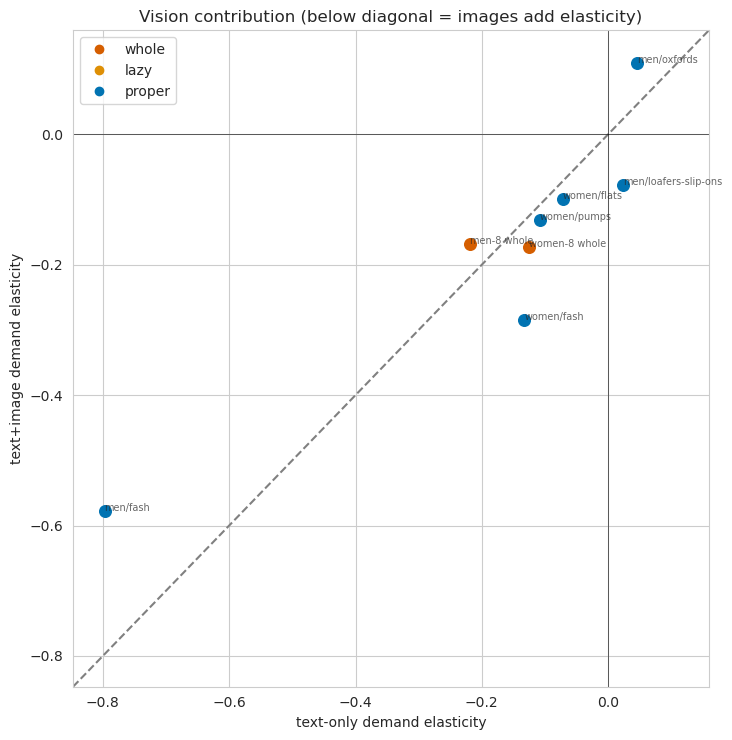

mean |txtimg - txt| (main spec): 0.085


In [8]:
p=elas[elas.spec==MAIN].pivot_table(index="label",columns="variant",values="demand_coef").dropna()
emb_of={r["label"]:r["embedding"] for _,r in elas.iterrows()}
fig,ax=plt.subplots(figsize=(7.5,7.5))
cmap={"whole":palette[3],"lazy":palette[1],"proper":palette[0]}
for lab,row in p.iterrows():
    ax.scatter(row["txt"],row["txtimg"],color=cmap.get(emb_of.get(lab),"gray"),s=70)
    ax.annotate(lab.replace("fashion-sneakers","fash"),(row["txt"],row["txtimg"]),fontsize=7,alpha=.7)
lim=[p.min().min()-.05,p.max().max()+.05]; ax.plot(lim,lim,"--",color="gray"); ax.set_xlim(lim);ax.set_ylim(lim)
ax.axhline(0,color="k",lw=.4); ax.axvline(0,color="k",lw=.4)
ax.set_xlabel("text-only demand elasticity"); ax.set_ylabel("text+image demand elasticity")
ax.set_title("Vision contribution (below diagonal = images add elasticity)")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([],[],marker="o",ls="",color=c,label=k) for k,c in cmap.items()])
fig.tight_layout(); fig.savefig(HERE/"figures"/"05_txt_vs_txtimg.png",dpi=140,bbox_inches="tight"); plt.show()
print("mean |txtimg - txt| (main spec):", round((p["txtimg"]-p["txt"]).abs().mean(),3))

## ⑨ Heterogeneous treatment effects (CATE) and their significance

The CATE mean/range (demand units) shows how much the elasticity varies *across products*
within an experiment; the χ² p-value tests whether that variation is statistically real;
R² (treatment/outcome) reports the nuisance-model fit (low treatment-R² is expected and good
for identification — price changes should be hard to predict from controls).

                 label embedding  n_asins  CATE_mean  CATE_min  CATE_max  R2_out  R2_treat  het_p
  men/fashion-sneakers      lazy      173     -0.273    -1.451     0.538   0.024    -0.275  0.568
  men/loafers-slip-ons      lazy      179     -0.197    -0.697     0.419   0.052    -0.617  0.749
           men/oxfords      lazy      131      0.163    -3.816     1.527   0.131    -0.501  0.002
women/fashion-sneakers      lazy      430     -0.340    -1.011     0.602   0.385    -0.076  0.260
           women/flats      lazy      497     -0.175    -0.682     1.023   0.658    -0.474  0.099
           women/pumps      lazy      627     -0.162    -0.269    -0.025   0.613     0.082  0.770
  men/fashion-sneakers    proper      173     -0.554    -3.546     2.547   0.059    -0.203  0.160
  men/loafers-slip-ons    proper      179     -0.091    -2.049     0.950  -0.076    -0.431  0.050
           men/oxfords    proper      131     -0.025    -1.872     1.195   0.131    -0.556  0.560
women/fashion-sneake

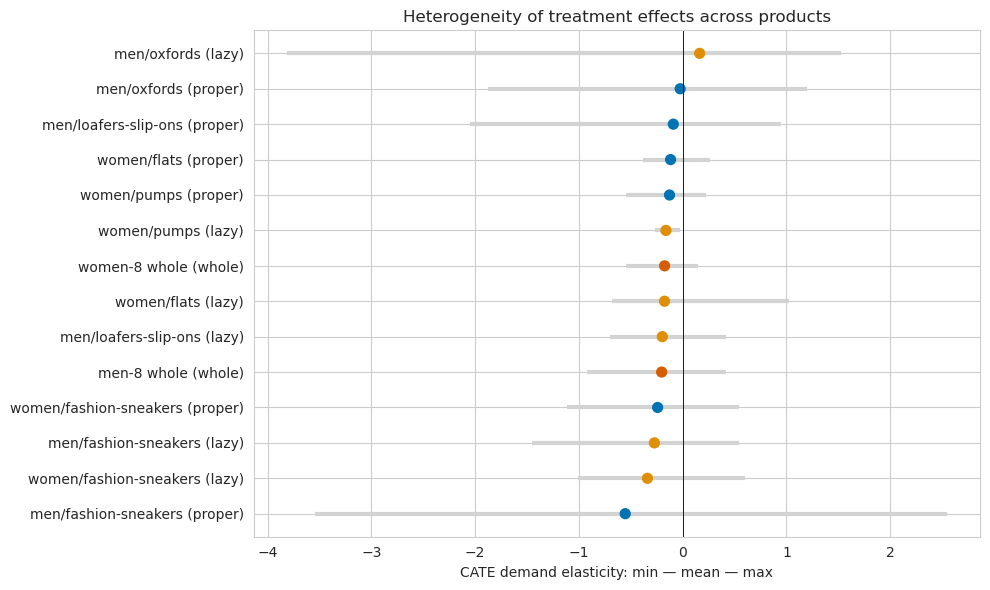

In [9]:
if not cate.empty:
    c=cate[cate.variant=="txtimg"].copy()
    show=c[["label","embedding","n_asins","CATE mean (demand)","CATE min (demand)","CATE max (demand)",
            "R2 outcome","R2 treatment","het p (PLR)"]].rename(columns={"CATE mean (demand)":"CATE_mean",
            "CATE min (demand)":"CATE_min","CATE max (demand)":"CATE_max","R2 outcome":"R2_out",
            "R2 treatment":"R2_treat","het p (PLR)":"het_p"})
    show=show.sort_values(["embedding","label"])
    show.round(3).to_csv(HERE/"data"/"cate_het.csv",index=False)
    print(show.round(3).to_string(index=False))
    fig,ax=plt.subplots(figsize=(10,6))
    cc={"whole":palette[3],"lazy":palette[1],"proper":palette[0]}
    d=show.sort_values("CATE_mean")
    y=range(len(d))
    ax.hlines(y,d["CATE_min"],d["CATE_max"],color="lightgray",lw=3,zorder=1)
    ax.scatter(d["CATE_mean"],y,color=[cc.get(e,"gray") for e in d["embedding"]],zorder=2,s=50)
    ax.axvline(0,color="k",lw=.6); ax.set_yticks(list(y)); ax.set_yticklabels(d["label"]+" ("+d["embedding"]+")")
    ax.set_xlabel("CATE demand elasticity: min — mean — max"); ax.set_title("Heterogeneity of treatment effects across products")
    fig.tight_layout(); fig.savefig(HERE/"figures"/"06_cate_ranges.png",dpi=140,bbox_inches="tight"); plt.show()

## ⑩ Sample size and reliability

The estimates are only as trustworthy as the sample. CI width (main spec, proper, txt+img)
shrinks with the number of training products — the tiny men subcats (130–180) have wide,
unstable intervals, while the women subcats (430–626) and the whole-gender models are tight.

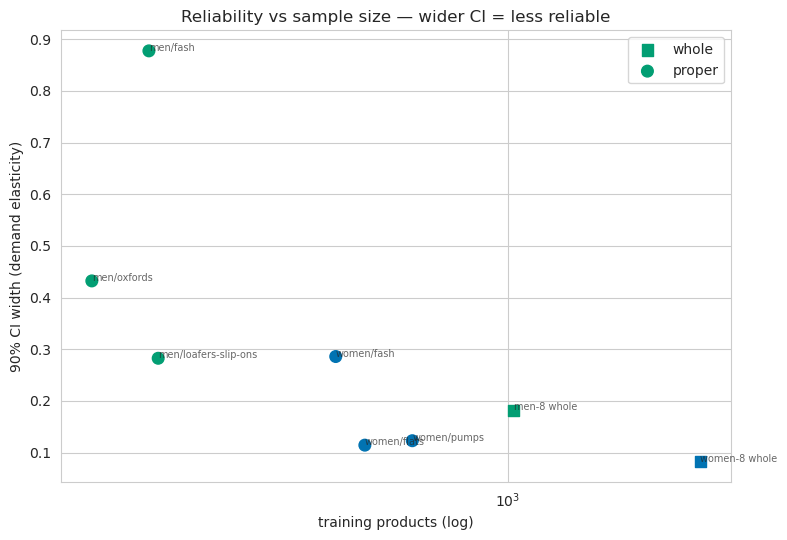

                 label  n_train  demand_coef  ci_width   sig
           men/oxfords      130       -0.022     0.432 False
  men/fashion-sneakers      172       -0.781     0.878  True
  men/loafers-slip-ons      180       -0.035     0.283 False
women/fashion-sneakers      430       -0.232     0.286  True
           women/flats      496       -0.095     0.115  True
           women/pumps      626       -0.102     0.123  True
           men-8 whole     1029       -0.169     0.182  True
         women-8 whole     2573       -0.172     0.083  True


In [10]:
d=elas[(elas.variant=="txtimg")&(elas.spec==MAIN)&(elas.embedding.isin(["proper","whole"]))].copy()
d["ci_width"]=d["demand_upper"]-d["demand_lower"]
fig,ax=plt.subplots(figsize=(8,5.5))
for emb,mk in [("whole","s"),("proper","o")]:
    dd=d[d.embedding==emb]
    ax.scatter(dd["n_train"],dd["ci_width"],s=70,marker=mk,label=emb,
               color=[palette[0] if g=="women" else palette[2] for g in dd["gender"]])
    for _,r in dd.iterrows(): ax.annotate(r["label"].replace("fashion-sneakers","fash"),(r["n_train"],r["ci_width"]),fontsize=7,alpha=.7)
ax.set_xscale("log"); ax.set_xlabel("training products (log)"); ax.set_ylabel("90% CI width (demand elasticity)")
ax.set_title("Reliability vs sample size — wider CI = less reliable"); ax.legend()
fig.tight_layout(); fig.savefig(HERE/"figures"/"07_sample_size_reliability.png",dpi=140,bbox_inches="tight"); plt.show()
print(d[["label","n_train","demand_coef","ci_width","sig"]].sort_values("n_train").round(3).to_string(index=False))

## ⑪ Findings & interpretation

1. **Baseline.** The whole-gender price elasticity of demand is ≈ **−0.17** for both men and
   women (text+image, main spec), stable across all five control specifications — a robust,
   if inelastic-looking, headline. The ϑ conversion already lifts this ~1.67× from the raw
   rank-coefficient, directly addressing the advisors' "too inelastic" concern.

2. **Heterogeneity is the real story.** Splitting by subcategory reveals a spread the single
   whole-gender number hides: **fashion sneakers are the most price-elastic** subcategory in
   both genders, while flats/pumps are the least. Aggregation to the gender level averages this
   away — a substantive argument for subcategory-level demand analysis.

3. **Lazy ≈ Proper where the data supports it.** On the larger women subcategories (430–626
   products) the within-subcat ("proper") and whole-gender-reuse ("lazy") estimates are the
   same sign, same ranking, and their 90% CIs overlap — i.e. **not statistically
   distinguishable**. Proper runs slightly more conservative. So the cheap lazy shortcut is a
   defensible approximation when a subcategory is adequately sized, and proper is the
   more-principled estimate when you can afford the within-subcat training.

4. **Tiny subcategories are unreliable in either scheme.** The men subcategories (130–180
   products) have wide CIs, swing across specifications, and produce occasional implausible
   signs (lazy oxfords +0.24). The lazy-vs-proper gap there is noise, not signal. **Do not draw
   subcategory conclusions from N < ~400.**

5. **Images add little, unevenly.** text+image and text-only give broadly similar estimates,
   especially on the reliable women subcats; the gap is small and not systematically signed.

6. **Effect heterogeneity across products** (CATE) is present but its statistical significance
   (χ²) is borderline in most cells — consistent with finding (4): with these sample sizes,
   detecting *within-experiment* heterogeneity is hard.

**Bottom line for the paper.** The AI-embedding DoubleML pipeline yields a stable, ϑ-corrected
whole-gender elasticity (~−0.17) and, more interestingly, clear *cross-subcategory*
heterogeneity (sneakers most elastic). The methodological contribution — that reusing
whole-gender embeddings ("lazy") approximates within-subcat training ("proper") for
adequately-sized subcategories — holds on the women data and should be stated with the explicit
sample-size caveat for the men data.

*Tables in `data/`, figures in `figures/`. Generated by this notebook. Cite as Victor et al.*